In [1]:
!pip install h5py

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import argparse
from pathlib import Path
from correlations_helper import *

In [3]:
def file_read(file_name):
    with h5py.File(file_name, "r") as h5f:
        e = h5f['incident_energies'][::].astype(np.float32)  
        shower = h5f['showers'][::].astype(np.float32)
        
    return e, shower

In [4]:
# provide the path to the generated samples and Geant4

score_path='/project/biocomplexity/fa7sa/calorimeter_evaluation_data/dataset_2/dataset_2_electron_CaloScore.h5'
geant_path='/project/biocomplexity/fa7sa/correlation_calorimeter/calodream/dataset_2_electron_Geant4.h5'
diff_path='/project/biocomplexity/fa7sa/calorimeter_evaluation_data/dataset_2/dataset_2_electron_CaloDiffusion.h5'
inn_path='/project/biocomplexity/fa7sa/calorimeter_evaluation_data/dataset_2/dataset_2_electron_CaloINN.h5'
dream_path='/project/biocomplexity/fa7sa/correlation_calorimeter/calodream/dataset_2_electron_CaloDream.hdf5'
E_score, s_score=file_read(score_path)
E_geant, s_geant=file_read(geant_path)
E_diff,s_diff=file_read(diff_path)
E_inn,s_inn=file_read(inn_path)
E_dream,s_dream=file_read(dream_path)

In [6]:
shape=[-1,45,16,9]
s_score=s_score.reshape(shape)
s_geant=s_geant.reshape(shape)
s_diff=s_diff.reshape(shape)
s_inn=s_inn.reshape(shape)
s_dream=s_dream.reshape(shape)

In [6]:
def generate_correlation_matrices(data):
    """
    Generate voxel-wise correlation matrices for consecutive layers.
    That means, correlation between layer i and layer i+1 for voxel j
    
    Parameters:
        data (ndarray): Input data of shape (100000, 45, 16, 9).
        
    Returns:
        correlation_matrices (list of ndarray): A list of correlation matrices (16x9) for each layer pair.
    """
    n_layers = data.shape[1]
    correlation_matrices = []

    # Iterate over each pair of consecutive layers
    for i in range(n_layers - 1):
        # Extract data for the two layers
        layer_data_1 = data[:, i, :, :].reshape(-1, 16, 9)  # Shape: (100000, 16, 9)
        layer_data_2 = data[:, i + 1, :, :].reshape(-1, 16, 9)  # Shape: (100000, 16, 9)

        # Initialize the correlation matrix for this layer pair
        correlation_matrix = np.zeros((16, 9))

        # Compute voxel-wise correlations
        for row in range(16):
            for col in range(9):
                corr, _ = pearsonr(layer_data_1[:, row, col], layer_data_2[:, row, col])
                correlation_matrix[row, col] = corr

        correlation_matrices.append(correlation_matrix)

    return np.array(correlation_matrices)


In [7]:
corr_diff=generate_correlation_matrices(s_diff)
corr_dream=generate_correlation_matrices(s_dream)
corr_geant=generate_correlation_matrices(s_geant)
corr_inn=generate_correlation_matrices(s_inn)
corr_score=generate_correlation_matrices(s_score)

In [16]:
frob_score = np.sqrt(np.sum((corr_geant - corr_score) ** 2))
frob_dream=np.sqrt(np.sum((corr_geant - corr_dream) ** 2))
frob_inn=np.sqrt(np.sum((corr_geant - corr_inn) ** 2))
frob_diff=np.sqrt(np.sum((corr_geant - corr_diff) ** 2))

frobs=[frob_diff, frob_dream, frob_inn, frob_score]
model_names = ["CaloDiffusion", "CaloDream", "CaloINN", "CaloScore"]

In [13]:
def plot_frob_norm(frobs,name,model_names):
    

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.bar(model_names, frobs, color='skyblue', edgecolor='black')

    # Customize the plot
    plt.xlabel("Models", fontsize=12)
    plt.ylabel("Frobenius Norm with Geant4", fontsize=12)
    plt.title(f"Frobenius Norm Comparison with Geant4 for {name} wise correlation", fontsize=14)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Show the plot
    plt.tight_layout()
    plt.savefig(f'frob_norm_{name}.pdf')

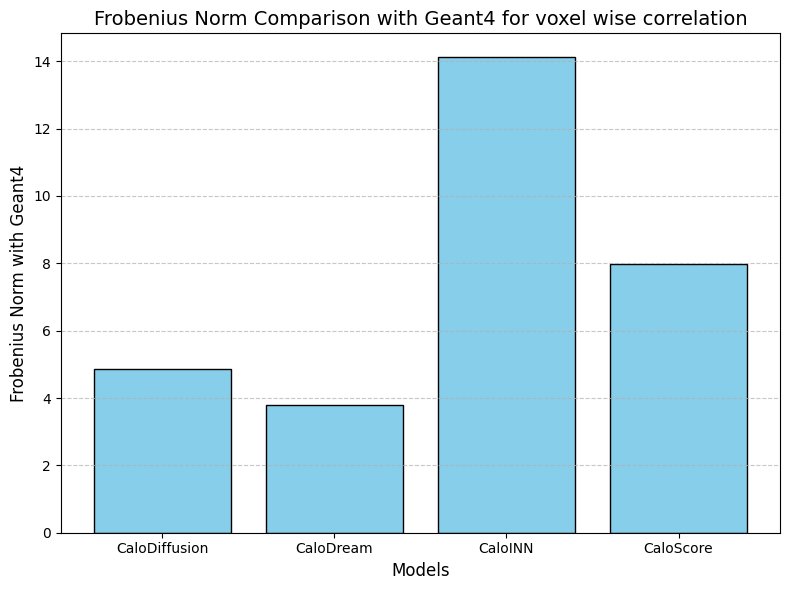

In [19]:
plot_frob_norm(frobs,'voxel',model_names)

In [10]:
def process_layer_sum(shower,shape=[-1,45,16,9,1]):
    samples=shower.shape[0]
    
    shower_ = shower.reshape(shape)
    layer_ = np.sum(shower_,(2,3,4),keepdims=True)
    layer_=layer_.reshape(samples,shape[1])
    
    return layer_

In [11]:
score_sum=process_layer_sum(s_score)
diff_sum=process_layer_sum(s_diff)
inn_sum=process_layer_sum(s_inn)
dream_sum=process_layer_sum(s_dream)
geant_sum=process_layer_sum(s_geant)

In [12]:
def calculateCorrelation(layer_real):
    dim=layer_real.shape[1]
    correlation_matrix = np.ones((dim, dim))
    p_value_matrix = np.zeros((dim, dim))

    # Loop through each pair of layers and compute correlations and p-values
    for i in range(dim):
        for j in range(dim):
            if i != j:  # Exclude self-correlation (diagonal elements)
                corr, p_value = pearsonr(layer_real[:, i], layer_real[:, j])
                correlation_matrix[i, j] = corr
                p_value_matrix[i, j] = p_value
                
                
    return correlation_matrix,p_value_matrix

(100000, 45)

In [20]:
layer_geant,_=calculateCorrelation(geant_sum)
layer_score,_=calculateCorrelation(score_sum)
layer_inn,_=calculateCorrelation(inn_sum)
layer_dream,_=calculateCorrelation(dream_sum)
layer_diff,_=calculateCorrelation(diff_sum)

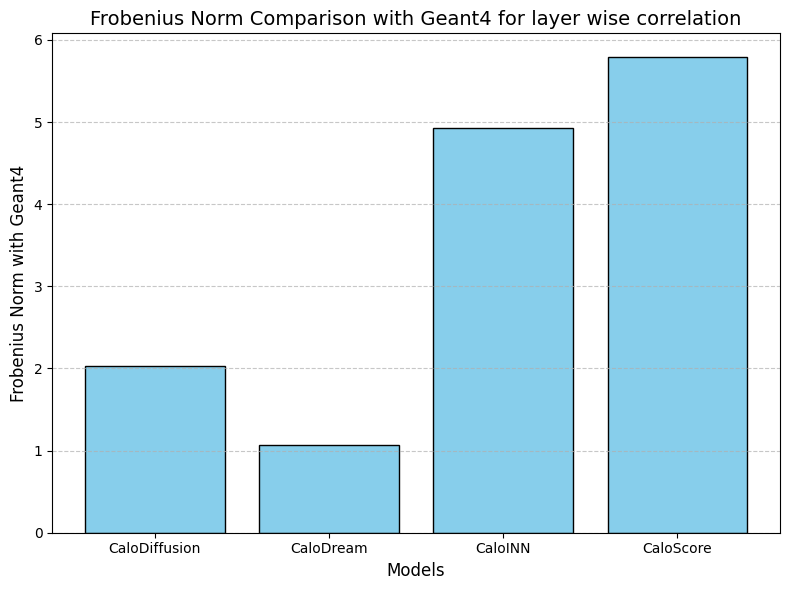

In [23]:
frob_score = np.sqrt(np.sum((layer_geant - layer_score) ** 2))
frob_dream=np.sqrt(np.sum((layer_geant - layer_dream) ** 2))
frob_inn=np.sqrt(np.sum((layer_geant - layer_inn) ** 2))
frob_diff=np.sqrt(np.sum((layer_geant - layer_diff) ** 2))

frobs=[frob_diff, frob_dream, frob_inn, frob_score]
model_names = ["CaloDiffusion", "CaloDream", "CaloINN", "CaloScore"]

plot_frob_norm(frobs,'layer',model_names)

In [7]:
def grouping_data(data):

    data=np.sum(data, axis=2)
    data = data.reshape(-1, 9, 5, 9)
    data = data.mean(axis=2)
    return data

d_geant=grouping_data(s_geant)
d_score=grouping_data(s_score)
d_diff=grouping_data(s_diff)
d_inn=grouping_data(s_inn)
d_dream=grouping_data(s_dream)

In [11]:
def generate_avg_correlation_matrices(data):
    """
    Generate voxel-wise correlation matrices for consecutive layers.
    
    Parameters:
        data (ndarray): Input data of shape (100000, 5, 16, 9).
        
    Returns:
        correlation_matrices (list of ndarray): A list of correlation matrices (16x9) for each layer pair.
    """
    n_layers = data.shape[1]
    correlation_matrices = []

    # Iterate over each pair of consecutive layers
    for i in range(n_layers - 1):
        # Extract data for the two layers
        layer_data_1 = data[:, i, :].reshape(-1, 9)  # Shape: (100000, 16, 9)
        layer_data_2 = data[:, i + 1, :].reshape(-1,  9)  # Shape: (100000, 16, 9)

        # Initialize the correlation matrix for this layer pair
        correlation_matrix = np.zeros((9))

        # Compute voxel-wise correlations

        for col in range(9):
            corr, _ = pearsonr(layer_data_1[:, col], layer_data_2[:, col])
            correlation_matrix[col] = corr

        correlation_matrices.append(correlation_matrix)

    return np.array(correlation_matrices)

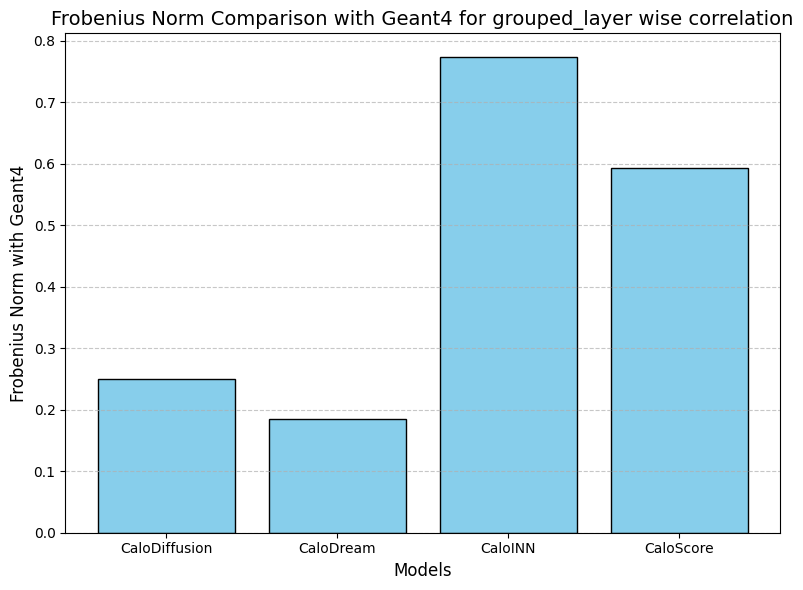

In [14]:
corr_geant=generate_avg_correlation_matrices(d_geant)
corr_score=generate_avg_correlation_matrices(d_score)
corr_diff=generate_avg_correlation_matrices(d_diff)
corr_inn=generate_avg_correlation_matrices(d_inn)
corr_dream=generate_avg_correlation_matrices(d_dream)

frob_score = np.sqrt(np.sum((corr_geant - corr_score) ** 2))
frob_dream=np.sqrt(np.sum((corr_geant - corr_dream) ** 2))
frob_inn=np.sqrt(np.sum((corr_geant - corr_inn) ** 2))
frob_diff=np.sqrt(np.sum((corr_geant - corr_diff) ** 2))

frobs=[frob_diff, frob_dream, frob_inn, frob_score]
model_names = ["CaloDiffusion", "CaloDream", "CaloINN", "CaloScore"]

plot_frob_norm(frobs,'grouped_layer',model_names)

In [ ]:
def plot_E_group_layers(ref_model, hlf_classes, model_names, plot_filename, e_range, dataset_num):
    """ plots energy deposited in 5 consecutive layers by creating a group of 5 layers"""
    # this is only applicable for dataset 2 and dataset 3. Dataset 1 does not need this

    fig, axs = plt.subplots(3, 3, figsize=(15, 15))
    
    keys = [[i+j for j in range(5)] for i in range(0, 45, 5)]
    axs = axs.flatten()

    print("Range: ", e_range)

    sep_powers_all = []
    layers_all = []

    for i, key in enumerate(keys):
        
        sep_powers = []
        layers = []

        ref_shape = hlf_classes[ref_model].GetElayers()[0].shape[0]
        ref_selected = [hlf_classes[ref_model].GetElayers()[i].reshape(ref_shape, 1)/1000 for i in key]#turning into GeV
        ref_combined = np.concatenate(ref_selected, axis=1)
        #ref_mean = np.mean(ref_combined, axis=1, keepdims=True) 
        ref_mean = np.sum(ref_combined, axis=1, keepdims=True) 

        if x_scale == 'log':
            bins = np.logspace(np.log10(min_energy),
                               np.log10(ref_mean.max()), 40)
        else:
            bins = 40

        ref_counts, bins, _ = axs[i].hist(ref_mean, bins=bins, label=ref_model, density=True, 
                            histtype='step',color=model_to_color[ref_model], alpha=0.2, linewidth=3.)

        this_layer = str(key[0]) + "-" + str(key[4]) 
        sep_powers.append(this_layer)
        sep_powers.append(0) # seperation power baseline, Geant4 with itself

        legend_names = ['Geant4']
            
        for j, model in enumerate(model_names):
            if model != ref_model:

                model_shape = hlf_classes[model].GetElayers()[0].shape[0]
                selected_hlf = [hlf_classes[model].GetElayers()[i].reshape(model_shape, 1)/1000 for i in key]#turning into GeV
                combined_hlf = np.concatenate(selected_hlf, axis=1)
                #hlf_means = np.mean(combined_hlf, axis=1, keepdims=True) 
                hlf_means = np.sum(combined_hlf, axis=1, keepdims=True) 
                model_counts, _, _ = axs[i].hist(hlf_means, label=model, bins=bins,
                                    histtype='step', color=model_to_color[model], linewidth=3., alpha=1., density=True)
            
                axs[i].set_title("layer {} to {}".format(key[0],key[4]))
                axs[i].set_xlabel(r'$E$ [GeV]')
                axs[i].set_yscale('log')
                axs[i].set_xscale('log')
            
                sep_power = calculate_separation_power(ref_counts, model_counts, bins)
                sep_powers.append(sep_power)

                legend_names.append(model)
           
        layers.append(str(key[0]) + "-" + str(key[4]))

        sep_powers_all.append(sep_powers)
        #print("separation power {} is {}, for layers {}".format(model_names, sep_powers, this_layer))

    # Plot E layers
    fig.legend(legend_names, fontsize=12, prop={'size': 10},
            loc='upper center', bbox_to_anchor=(0.5, 1.0), ncols=4)
    plt.tight_layout(pad=3.0)
    
    plt.savefig(plot_filename, dpi=300)

    # get the colors matching the order in legend_names
    colors = []
    for model in legend_names:
        colors.append(model_to_color[model])

    # Plot chi-squared a.k.a seperation power 
    legend_names.insert(0, 'Layers')
    df = pd.DataFrame(sep_powers_all, columns=legend_names)
    df.plot(x='Layers', y=legend_names[1:], color=colors, figsize=(10,5))
    # Set the x-axis label
    plt.xlabel('Layers')
    # Set the y-axis label
    plt.ylabel('Separation power')
    plt.legend(ncol=4, bbox_to_anchor=(0.5, 0.98),
           loc='upper center', fontsize=12)
    # save plot
    plt.savefig("sep_pow_ds" + str(dataset_num) + "_" + e_range + ".pdf", bbox_inches='tight', dpi=300)

    plt.close()
